In [2]:
import pandas as pd
import numpy as np

In [3]:
from google.colab import files
uploaded = files.upload()

Saving olist_dataset.zip to olist_dataset.zip


In [4]:
import zipfile

with zipfile.ZipFile("olist_dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("olist_data")

In [5]:
orders = pd.read_csv("olist_data/olist_orders_dataset.csv")
items = pd.read_csv("olist_data/olist_order_items_dataset.csv")
payments = pd.read_csv("olist_data/olist_order_payments_dataset.csv")
reviews = pd.read_csv("olist_data/olist_order_reviews_dataset.csv")
customers = pd.read_csv("olist_data/olist_customers_dataset.csv")

In [6]:
print("Orders:", orders.shape)
print("Items:", items.shape)
print("Payments:", payments.shape)
print("Reviews:", reviews.shape)
print("Customers:", customers.shape)

Orders: (99441, 8)
Items: (112650, 7)
Payments: (103886, 5)
Reviews: (99224, 7)
Customers: (99441, 5)


In [7]:
df = orders.merge(items, on='order_id')
df = df.merge(payments, on='order_id')
df = df.merge(reviews, on='order_id')
df = df.merge(customers, on='customer_id')

In [8]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,...,8d5266042046a06655c8db133d120ba5,4,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,...,e73b67b67587f7644d5bd1a52deb1b01,5,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO


In [9]:
df.shape

(117329, 28)

In [10]:
df.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,15
order_delivered_carrier_date,1235
order_delivered_customer_date,2471
order_estimated_delivery_date,0
order_item_id,0
product_id,0


In [11]:
df['review_score'].value_counts()

,count
review_score,
5,66264
4,22286
1,14854
3,9840
2,4085


In [12]:
df['review_score'].value_counts(normalize=True) * 100

,proportion
review_score,
5,56.477086
4,18.994451
1,12.660127
3,8.386673
2,3.481663


In [13]:
df['positive_review'] = df['review_score'].apply(lambda x: 1 if x == 5 else 0)
df['positive_review'].value_counts()



,count
positive_review,
1,66264
0,51065


In [14]:
df['positive_review'].value_counts(normalize=True) * 100

,proportion
positive_review,
1,56.477086
0,43.522914


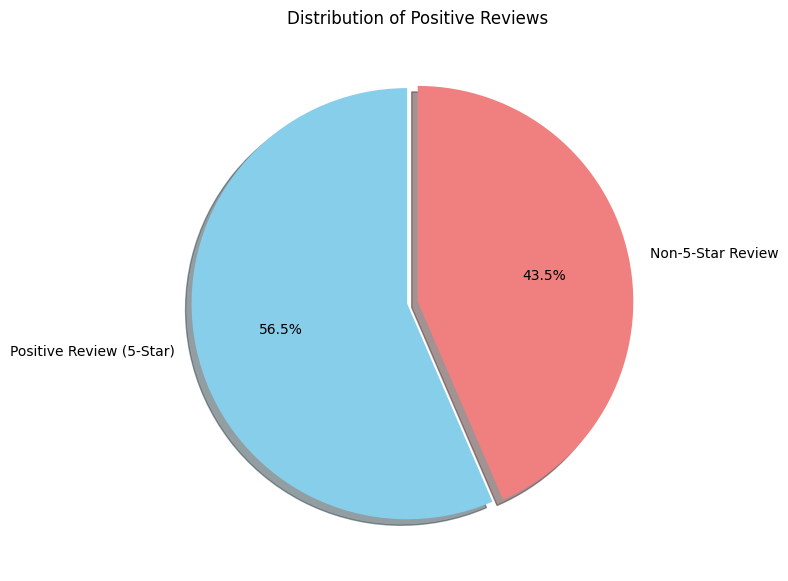

In [15]:
import matplotlib.pyplot as plt

review_counts = df['positive_review'].value_counts()

labels = ['Positive Review (5-Star)', 'Non-5-Star Review']
colors = ['skyblue', 'lightcoral']

plt.figure(figsize=(7,7))

plt.pie(
    review_counts,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    explode=(0.05, 0),
    shadow=True
)

plt.title('Distribution of Positive Reviews')

plt.show()

In [16]:
df = df.drop(columns=[
    'review_comment_title',
    'review_comment_message',
    'review_id'
])

In [17]:
df.dtypes

,0
order_id,object
customer_id,object
order_status,object
order_purchase_timestamp,object
order_approved_at,object
order_delivered_carrier_date,object
order_delivered_customer_date,object
order_estimated_delivery_date,object
order_item_id,int64
product_id,object


In [18]:
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col])

In [19]:
df[date_columns].dtypes

,0
order_purchase_timestamp,datetime64[ns]
order_approved_at,datetime64[ns]
order_delivered_customer_date,datetime64[ns]
order_estimated_delivery_date,datetime64[ns]


In [20]:
#Delivery Time = How many days the customer waited.
df['delivery_time'] = (
    df['order_delivered_customer_date']
    - df['order_purchase_timestamp']
).dt.days

In [21]:
#Delivery Delay
df['delivery_delay'] = (
    df['order_delivered_customer_date']
    - df['order_estimated_delivery_date']
).dt.days

In [22]:
df[['delivery_time', 'delivery_delay']].isnull().sum()
df = df.dropna(subset=['delivery_time', 'delivery_delay'])

In [23]:
ml_df = df[[
    'price',
    'freight_value',
    'payment_value',
    'payment_installments',
    'delivery_time',
    'delivery_delay',
    'review_score',
    'positive_review'
]]

In [24]:
ml_df.head()

,price,freight_value,payment_value,payment_installments,delivery_time,delivery_delay,review_score,positive_review
0,29.99,8.72,18.12,1,8.0,-8.0,4,0
1,29.99,8.72,2.00,1,8.0,-8.0,4,0
2,29.99,8.72,18.59,1,8.0,-8.0,4,0
3,118.70,22.76,141.46,1,13.0,-6.0,4,0
4,159.90,19.22,179.12,3,9.0,-18.0,5,1


In [25]:
ml_df.shape

(114858, 8)

In [26]:
ml_df.isnull().sum()

,0
price,0
freight_value,0
payment_value,0
payment_installments,0
delivery_time,0
delivery_delay,0
review_score,0
positive_review,0


In [27]:
ml_df.describe()

,price,freight_value,payment_value,payment_installments,delivery_time,delivery_delay,review_score,positive_review
count,114858.000000,114858.000000,114858.000000,114858.000000,114858.000000,114858.000000,114858.000000,114858.000000
mean,119.769920,19.974475,171.253080,2.937819,11.979375,-12.084574,4.080438,0.574980
std,181.424435,15.703406,263.765652,2.773740,9.371316,10.094451,1.347673,0.494348
min,0.850000,0.000000,0.000000,0.000000,0.000000,-147.000000,1.000000,0.000000
25%,39.900000,13.080000,60.720000,1.000000,6.000000,-17.000000,4.000000,0.000000
50%,74.900000,16.280000,108.000000,2.000000,10.000000,-13.000000,5.000000,1.000000
75%,132.900000,21.150000,188.690000,4.000000,15.000000,-7.000000,5.000000,1.000000
max,6735.000000,409.680000,13664.080000,24.000000,208.000000,188.000000,5.000000,1.000000


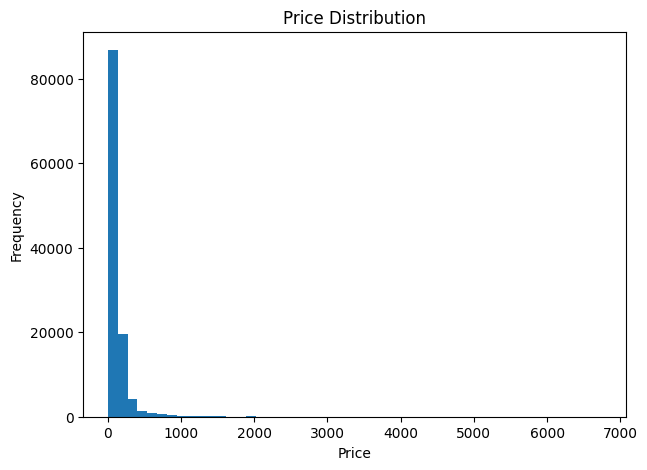

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.hist(ml_df['price'], bins=50)

plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')

plt.show()

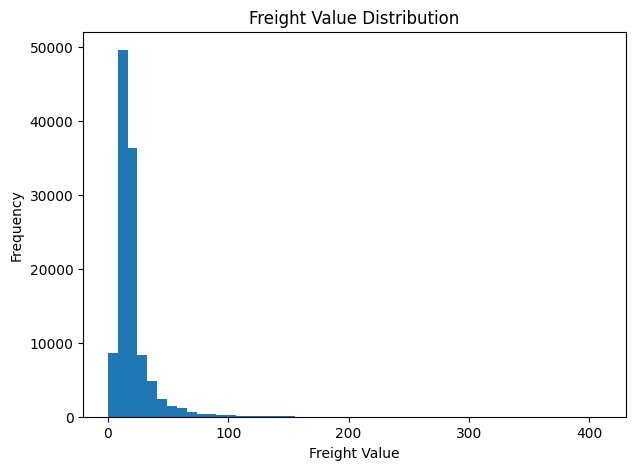

In [29]:
plt.figure(figsize=(7,5))

plt.hist(ml_df['freight_value'], bins=50)

plt.title('Freight Value Distribution')
plt.xlabel('Freight Value')
plt.ylabel('Frequency')

plt.show()

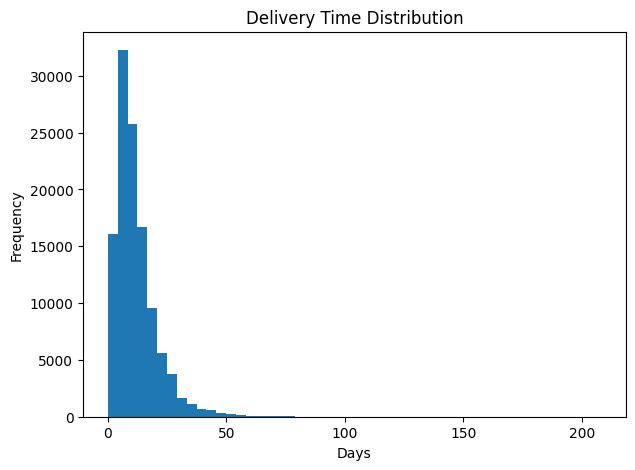

In [30]:
plt.figure(figsize=(7,5))

plt.hist(ml_df['delivery_time'], bins=50)

plt.title('Delivery Time Distribution')
plt.xlabel('Days')
plt.ylabel('Frequency')

plt.show()

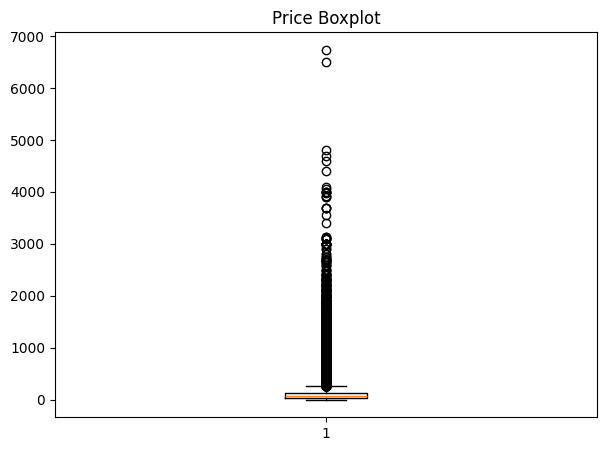

In [31]:
plt.figure(figsize=(7,5))

plt.boxplot(ml_df['price'])

plt.title('Price Boxplot')

plt.show()

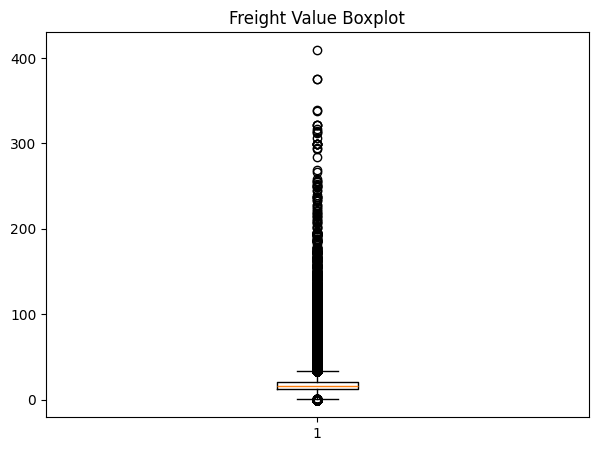

In [32]:
plt.figure(figsize=(7,5))

plt.boxplot(ml_df['freight_value'])

plt.title('Freight Value Boxplot')

plt.show()

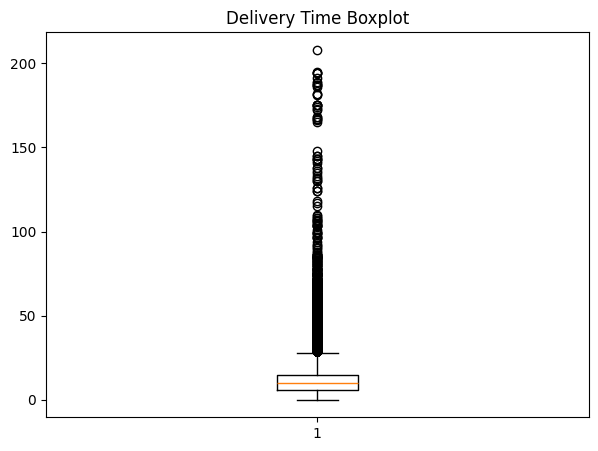

In [33]:
plt.figure(figsize=(7,5))

plt.boxplot(ml_df['delivery_time'])

plt.title('Delivery Time Boxplot')

plt.show()

In [34]:
ml_df.groupby('positive_review').mean()

,price,freight_value,payment_value,payment_installments,delivery_time,delivery_delay,review_score
positive_review,,,,,,,
0,117.770638,20.476895,185.475514,2.995248,14.382162,-10.246267,2.83643
1,121.247775,19.603090,160.739966,2.895368,10.203253,-13.443437,5.00000


In [35]:
corr_cols = [
    'price',
    'freight_value',
    'payment_value',
    'payment_installments',
    'delivery_time',
    'delivery_delay',
    'review_score'
]

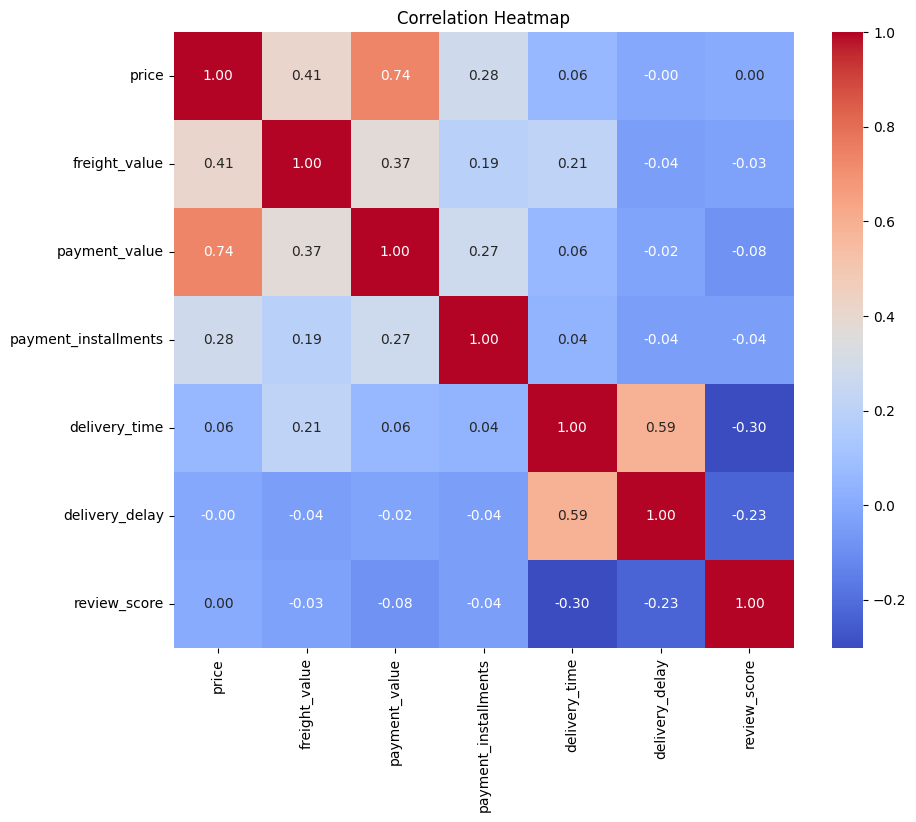

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

corr_matrix = ml_df[corr_cols].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

In [37]:
cluster_features = [
    'price',
    'freight_value',
    'payment_value',
    'delivery_time',
    'delivery_delay'
]

In [38]:
import pandas as pd

# Load datasets
orders = pd.read_csv("olist_data/olist_orders_dataset.csv")
items = pd.read_csv("olist_data/olist_order_items_dataset.csv")
payments = pd.read_csv("olist_data/olist_order_payments_dataset.csv")
reviews = pd.read_csv("olist_data/olist_order_reviews_dataset.csv")
customers = pd.read_csv("olist_data/olist_customers_dataset.csv")

# Merge datasets to create df
df = orders.merge(items, on='order_id')
df = df.merge(payments, on='order_id')
df = df.merge(reviews, on='order_id')
df = df.merge(customers, on='customer_id')

# Create 'positive_review' column
df['positive_review'] = df['review_score'].apply(lambda x: 1 if x == 5 else 0)

# Convert date columns to datetime objects
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_columns:
    df[col] = pd.to_datetime(df[col])

# Create 'delivery_time' and 'delivery_delay' columns
df['delivery_time'] = (
    df['order_delivered_customer_date']
    - df['order_purchase_timestamp']
).dt.days
df['delivery_delay'] = (
    df['order_delivered_customer_date']
    - df['order_estimated_delivery_date']
).dt.days

# Drop rows with NaN in 'delivery_time' or 'delivery_delay'
df = df.dropna(subset=['delivery_time', 'delivery_delay'])

# Define ml_df
ml_df = df[[
    'price',
    'freight_value',
    'payment_value',
    'payment_installments',
    'delivery_time',
    'delivery_delay',
    'review_score',
    'positive_review'
]]

In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    ml_df[cluster_features]
)

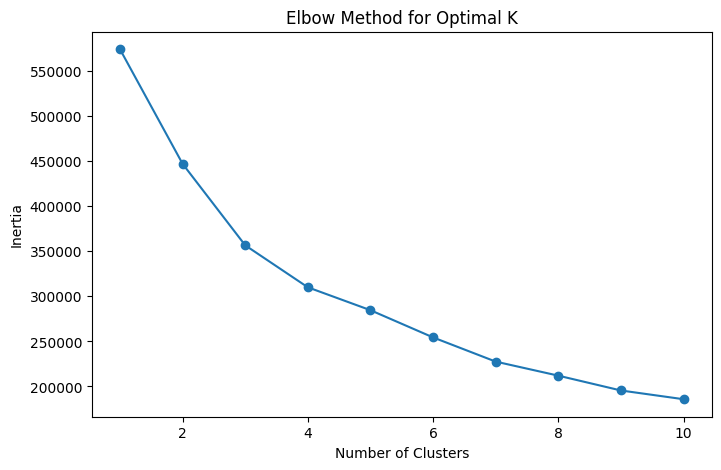

In [40]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K = range(1,11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(K, inertia, marker='o')

plt.xlabel('Number of Clusters')

plt.ylabel('Inertia')

plt.title('Elbow Method for Optimal K')

plt.show()

K = 2, Silhouette Score = 0.6560
K = 3, Silhouette Score = 0.4562
K = 4, Silhouette Score = 0.4542
K = 5, Silhouette Score = 0.2751
K = 6, Silhouette Score = 0.2470
K = 7, Silhouette Score = 0.2571
K = 8, Silhouette Score = 0.2574
K = 9, Silhouette Score = 0.2592
K = 10, Silhouette Score = 0.2556


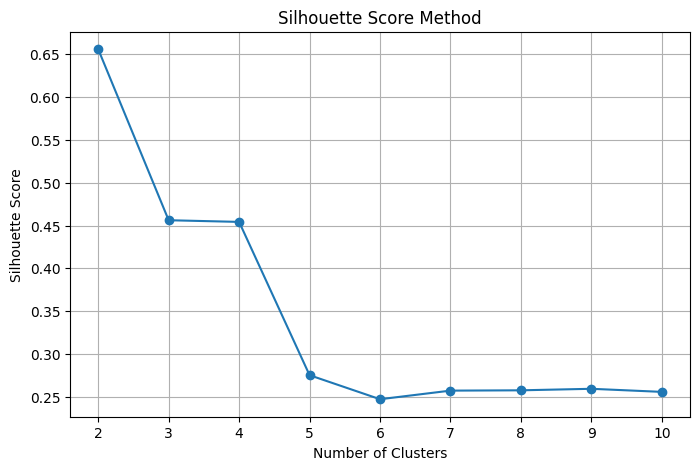

In [41]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

silhouette_scores = []

K = range(2, 11)

for k in K:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    cluster_labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        cluster_labels,
        sample_size=10000,
        random_state=42
    )

    silhouette_scores.append(score)

    print(f"K = {k}, Silhouette Score = {score:.4f}")

plt.figure(figsize=(8,5))

plt.plot(
    K,
    silhouette_scores,
    marker='o'
)

plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score Method')
plt.grid(True)

plt.show()

In [42]:
kmeans = KMeans(
    n_clusters=K[-1], # Using the last K from the previous loop which was 10
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(X_scaled)

df['Cluster'].value_counts()

,count
Cluster,
9,49518
3,25533
0,22392
5,7017
6,4613
4,4239
2,796
1,649
7,81


In [43]:
df.groupby('Cluster').mean(numeric_only=True)

,order_item_id,price,freight_value,payment_sequential,payment_installments,payment_value,review_score,customer_zip_code_prefix,positive_review,delivery_time,delivery_delay
Cluster,,,,,,,,,,,
0,1.168453,91.573914,18.642441,1.108387,2.749151,129.836892,3.878617,44429.654877,0.486245,19.251027,-6.271302
1,1.077042,1666.624237,55.120570,1.029276,6.654854,1799.920863,4.041602,40681.640986,0.602465,13.109399,-13.294299
2,1.218593,504.824033,130.008354,1.219849,5.366834,747.082349,3.826633,49598.577889,0.525126,17.706030,-12.047739
3,1.211530,96.527043,18.747122,1.072690,3.042572,144.225957,4.217992,41642.601731,0.620099,9.181647,-22.791133
4,1.128332,117.293918,23.167799,1.063694,3.093890,157.708028,1.889125,44919.785563,0.100967,40.160415,13.038688
5,1.148782,170.390708,50.696841,1.079094,3.938720,253.672434,4.131965,47045.426108,0.573179,13.932022,-14.609805
6,1.578582,504.390685,27.441140,1.051593,5.487752,746.180648,3.991546,37666.696293,0.547800,11.912855,-13.008888
7,1.074074,198.030617,23.852716,1.037037,3.382716,236.718519,2.938272,38373.518519,0.246914,138.160494,110.185185
8,3.450000,1988.430000,45.393500,1.000000,1.350000,9427.868500,1.400000,29330.100000,0.100000,16.550000,-7.950000


In [44]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

print(df['Cluster'].value_counts())

Cluster
0    109622
1      5236
Name: count, dtype: int64


In [45]:
df.groupby('Cluster')[
[
'payment_value',
'freight_value',
'delivery_time',
'review_score'
]
].mean()

,payment_value,freight_value,delivery_time,review_score
Cluster,,,,
0,136.082552,18.128519,11.807776,4.089042
1,907.590674,58.621799,15.572002,3.900306


In [46]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

print(df['Cluster'].value_counts())

print(
    df.groupby('Cluster')[
        ['payment_value',
         'freight_value',
         'delivery_time',
         'review_score']
    ].mean()
)

Cluster
0    95199
1    15415
2     4244
Name: count, dtype: int64
         payment_value  freight_value  delivery_time  review_score
Cluster                                                           
0           135.872412      17.597705       9.233994      4.238259
1           158.986673      23.607012      28.458579      3.134415
2          1009.446044      60.094774      13.706645      3.976437


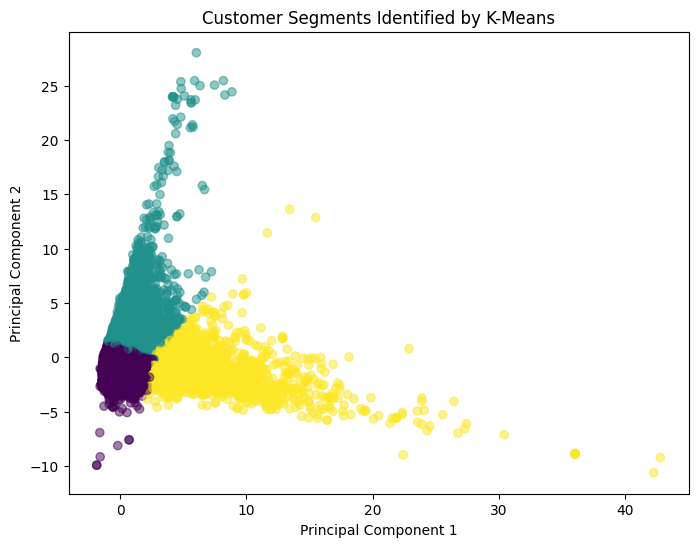

In [47]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    cmap='viridis',
    alpha=0.5
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segments Identified by K-Means")

plt.show()

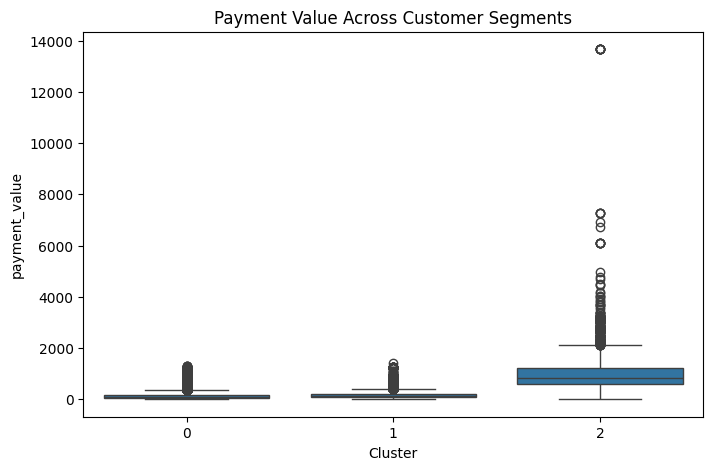

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.boxplot(
    x='Cluster',
    y='payment_value',
    data=df
)

plt.title('Payment Value Across Customer Segments')

plt.show()

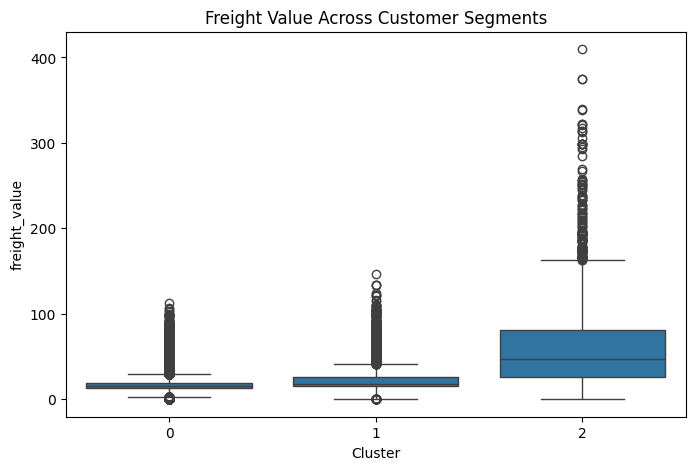

In [49]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Cluster',
    y='freight_value',
    data=df
)

plt.title('Freight Value Across Customer Segments')

plt.show()

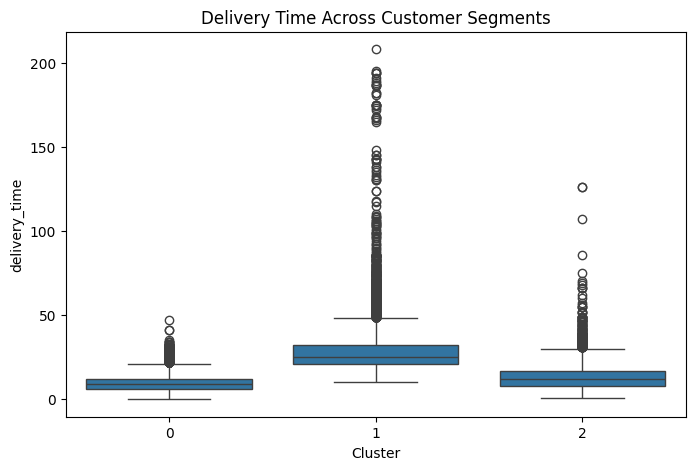

In [50]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Cluster',
    y='delivery_time',
    data=df
)

plt.title('Delivery Time Across Customer Segments')

plt.show()

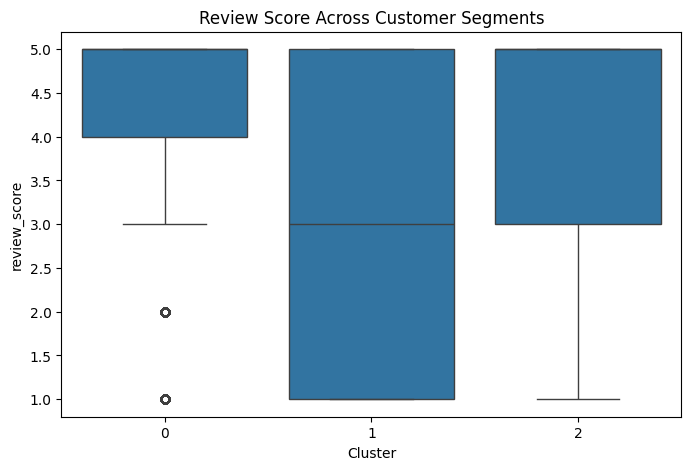

In [51]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Cluster',
    y='review_score',
    data=df
)

plt.title('Review Score Across Customer Segments')

plt.show()

In [52]:
print(X_scaled.shape)

(114858, 5)


In [53]:
import numpy as np

sample_size = 2000

indices = np.random.choice(
    len(X_scaled),
    sample_size,
    replace=False
)

X_sample = X_scaled[indices]

In [54]:
from scipy.cluster.hierarchy import linkage

linked = linkage(
    X_sample,
    method='ward'
)

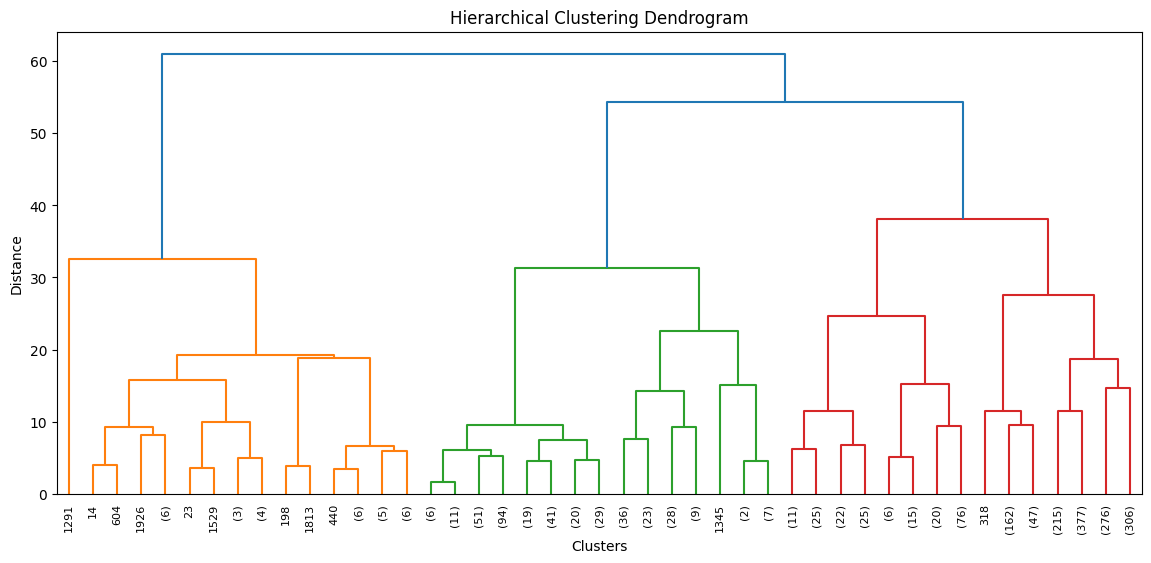

In [55]:
from scipy.cluster.hierarchy import dendrogram
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

dendrogram(
    linked,
    truncate_mode='level',
    p=5
)

plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Clusters')
plt.ylabel('Distance')

plt.show()

In [56]:
print(cluster_features)

['price', 'freight_value', 'payment_value', 'delivery_time', 'delivery_delay']


In [57]:
import numpy as np

sample_size = 2000

indices = np.random.choice(
    len(X_scaled),
    sample_size,
    replace=False
)

X_sample = X_scaled[indices]

In [58]:
from sklearn.cluster import AgglomerativeClustering

agg_cluster = AgglomerativeClustering(
    n_clusters=3,
    linkage='ward'
)

agg_labels = agg_cluster.fit_predict(X_sample)

In [59]:
sample_df = df.iloc[indices].copy()

sample_df['Agg_Cluster'] = agg_labels

In [60]:
print(
    sample_df['Agg_Cluster'].value_counts()
)

print(
    sample_df.groupby('Agg_Cluster')[
        [
            'price',
            'freight_value',
            'payment_value',
            'delivery_time',
            'delivery_delay'
        ]
    ].mean()
)

Agg_Cluster
1    1831
0      90
2      79
Name: count, dtype: int64
                  price  freight_value  payment_value  delivery_time  \
Agg_Cluster                                                            
0            562.885222      70.535000     820.207111      13.977778   
1             98.762059      17.289454     139.591660      10.523211   
2             82.430253      19.656709     121.864684      40.848101   

             delivery_delay  
Agg_Cluster                  
0                -13.222222  
1                -13.143637  
2                 14.898734  


In [61]:
print(df['review_score'].value_counts().sort_index())

review_score
1    13118
2     3899
3     9650
4    22150
5    66041
Name: count, dtype: int64


In [62]:
df[['payment_installments', 'review_score']].corr()

,payment_installments,review_score
payment_installments,1.000000,-0.042869
review_score,-0.042869,1.000000


In [63]:
df['customer_satisfaction'] = (
    df['review_score'] == 5
).astype(int)

print(df['customer_satisfaction'].value_counts())

customer_satisfaction
1    66041
0    48817
Name: count, dtype: int64


In [64]:
features = [
    'price',
    'payment_value',
    'payment_installments',
    'freight_value',
    'delivery_time',
    'delivery_delay'
]

X = df[features]

y = df['customer_satisfaction']

In [65]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [66]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [67]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

model.fit(
    X_train_scaled,
    y_train
)

LogisticRegression(max_iter=1000, random_state=42)

In [68]:
print(model.score(X_test_scaled, y_test))

0.6315949851993732


In [69]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

y_pred = model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.6315949851993732

Confusion Matrix:
[[ 2931  6833]
 [ 1630 11578]]

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.30      0.41      9764
           1       0.63      0.88      0.73     13208

    accuracy                           0.63     22972
   macro avg       0.64      0.59      0.57     22972
weighted avg       0.63      0.63      0.60     22972



In [70]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test_scaled)[:,1]

auc = roc_auc_score(
    y_test,
    y_prob
)

print("ROC-AUC:", auc)

ROC-AUC: 0.6369719768734751


In [71]:
coefficients = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_[0]
})

coefficients.sort_values(
    by='Coefficient',
    ascending=False
)

,Feature,Coefficient
0,price,0.315628
3,freight_value,0.061069
2,payment_installments,-0.013058
5,delivery_delay,-0.134365
1,payment_value,-0.401903
4,delivery_time,-0.480419


In [72]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

dt_model.fit(
    X_train_scaled,
    y_train
)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [73]:
y_pred_dt = dt_model.predict(
    X_test_scaled
)

In [74]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        y_pred_dt
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred_dt
    )
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_dt
    )
)

y_prob_dt = dt_model.predict_proba(
    X_test_scaled
)[:,1]

print(
    "\nROC-AUC:",
    roc_auc_score(
        y_test,
        y_prob_dt
    )
)

Accuracy: 0.6308114226014279

Confusion Matrix:
[[ 2415  7349]
 [ 1132 12076]]

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.25      0.36      9764
           1       0.62      0.91      0.74     13208

    accuracy                           0.63     22972
   macro avg       0.65      0.58      0.55     22972
weighted avg       0.65      0.63      0.58     22972


ROC-AUC: 0.6234515082910037


In [75]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': dt_model.feature_importances_
})

feature_importance.sort_values(
    by='Importance',
    ascending=False
)

,Feature,Importance
5,delivery_delay,0.698110
4,delivery_time,0.197210
0,price,0.046570
3,freight_value,0.037012
1,payment_value,0.017953
2,payment_installments,0.003145


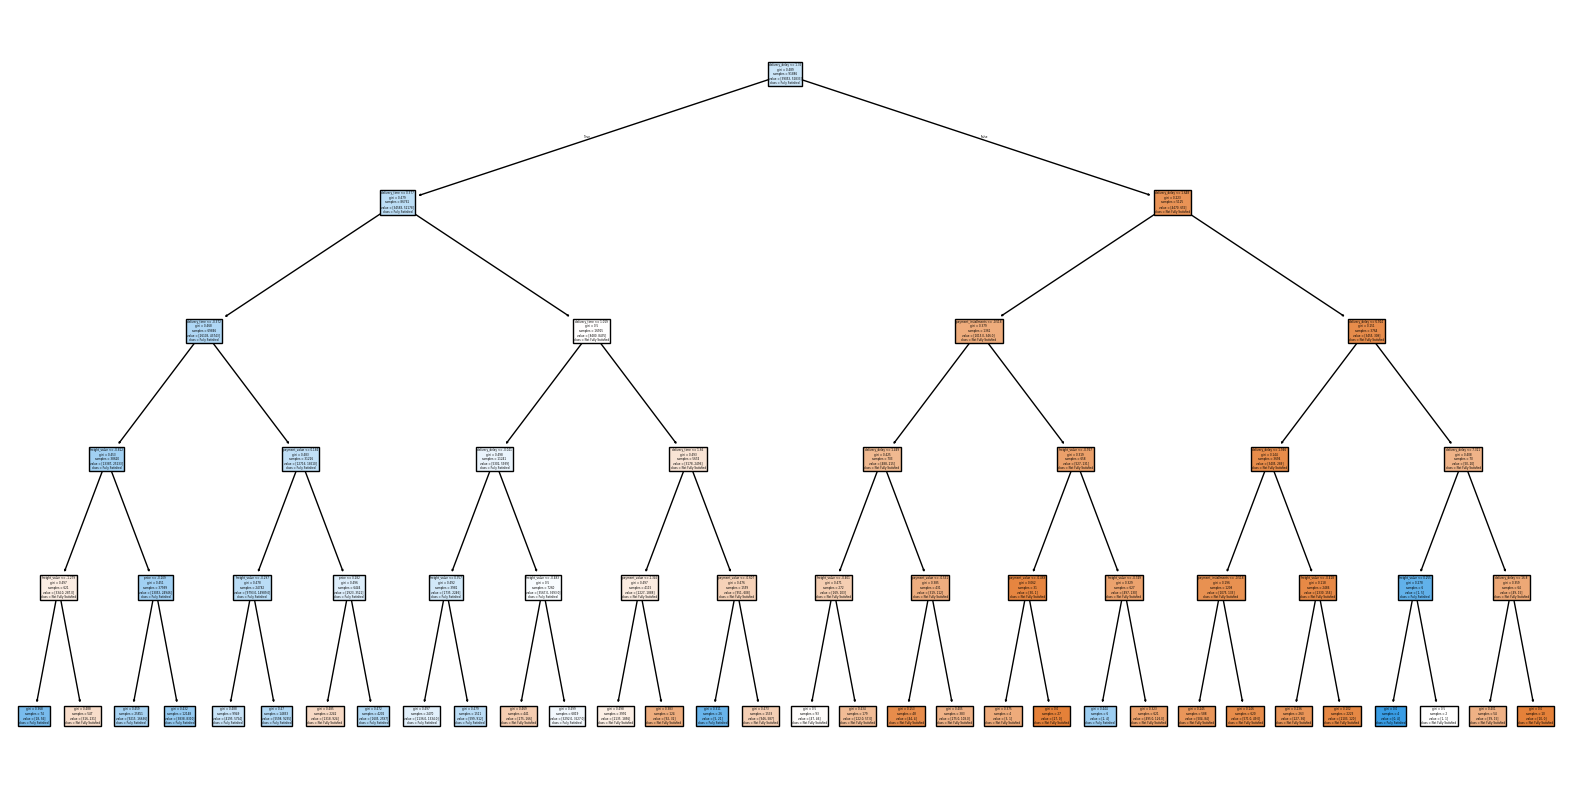

In [76]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(
    figsize=(20,10)
)

plot_tree(
    dt_model,
    feature_names=features,
    class_names=[
        'Not Fully Satisfied',
        'Fully Satisfied'
    ],
    filled=True
)

plt.show()

In [77]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [78]:
y_pred_rf = rf_model.predict(X_test)

y_prob_rf = rf_model.predict_proba(X_test)[:,1]

In [79]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        y_pred_rf
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred_rf
    )
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

print(
    "\nROC-AUC:",
    roc_auc_score(
        y_test,
        y_prob_rf
    )
)

Accuracy: 0.6863137732892216

Confusion Matrix:
[[ 5000  4764]
 [ 2442 10766]]

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.51      0.58      9764
           1       0.69      0.82      0.75     13208

    accuracy                           0.69     22972
   macro avg       0.68      0.66      0.67     22972
weighted avg       0.68      0.69      0.68     22972


ROC-AUC: 0.7323663721241034


In [80]:
import pandas as pd

rf_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
})

rf_importance.sort_values(
    by='Importance',
    ascending=False
)

,Feature,Importance
1,payment_value,0.228387
0,price,0.199720
3,freight_value,0.193922
5,delivery_delay,0.184012
4,delivery_time,0.125559
2,payment_installments,0.068400


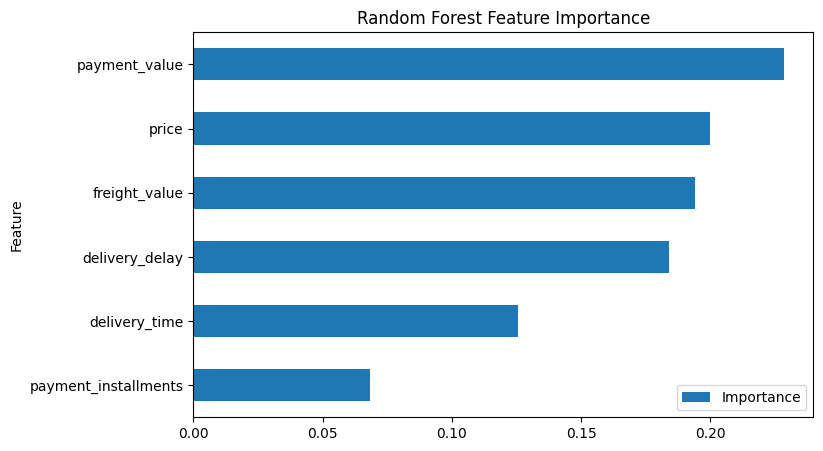

In [81]:
import matplotlib.pyplot as plt

rf_importance.sort_values(
    by='Importance'
).plot(
    x='Feature',
    y='Importance',
    kind='barh',
    figsize=(8,5)
)

plt.title(
    'Random Forest Feature Importance'
)

plt.show()

In [82]:
df['review_score'].value_counts()

,count
review_score,
5,66041
4,22150
1,13118
3,9650
2,3899


In [83]:
from scipy.stats import f_oneway

cluster0 = df[df['Cluster']==0]['review_score']
cluster1 = df[df['Cluster']==1]['review_score']
cluster2 = df[df['Cluster']==2]['review_score']

f_stat, p_value = f_oneway(
    cluster0,
    cluster1,
    cluster2
)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 4839.392909576879
P-value: 0.0


In [84]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(
    df['Cluster'],
    df['customer_satisfaction']
)

chi2, p, dof, expected = chi2_contingency(
    contingency_table
)

print("Chi-square:", chi2)
print("P-value:", p)

Chi-square: 4456.948004329453
P-value: 0.0


In [85]:
import numpy as np

odds_ratios = pd.DataFrame({
    'Feature': X.columns,
    'Odds Ratio': np.exp(model.coef_[0])
})

print(
    odds_ratios.sort_values(
        by='Odds Ratio',
        ascending=False
    )
)

                Feature  Odds Ratio
0                 price    1.371121
3         freight_value    1.062973
2  payment_installments    0.987027
5        delivery_delay    0.874271
1         payment_value    0.669046
4         delivery_time    0.618524


In [86]:
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [87]:
!ls

olist_data  olist_dataset.zip  sample_data


In [88]:
%%writefile app.py
import streamlit as st

st.title("Customer Satisfaction Prediction System")

price = st.number_input("Price")
payment_value = st.number_input("Payment Value")
payment_installments = st.number_input("Payment Installments")
freight_value = st.number_input("Freight Value")
delivery_time = st.number_input("Delivery Time")
delivery_delay = st.number_input("Delivery Delay")

if st.button("Predict"):

    if delivery_time < 15 and delivery_delay < 0:
        st.success("Satisfied Customer")
    else:
        st.error("Dissatisfied Customer")

Writing app.py


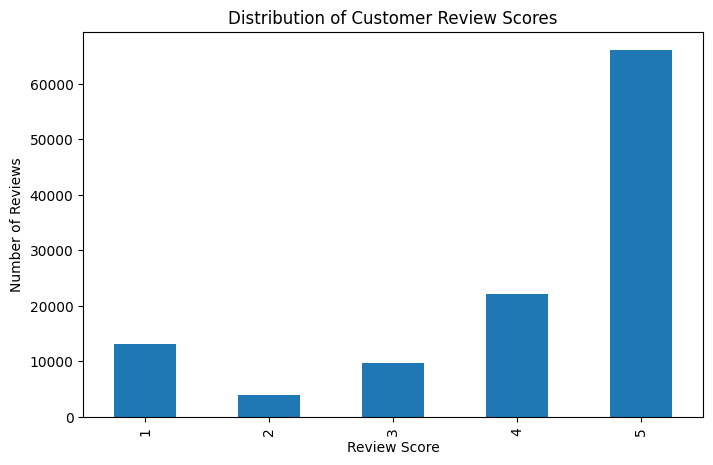

In [89]:
import matplotlib.pyplot as plt

review_counts = df['review_score'].value_counts().sort_index()

plt.figure(figsize=(8,5))
review_counts.plot(kind='bar')

plt.title('Distribution of Customer Review Scores')
plt.xlabel('Review Score')
plt.ylabel('Number of Reviews')

plt.show()

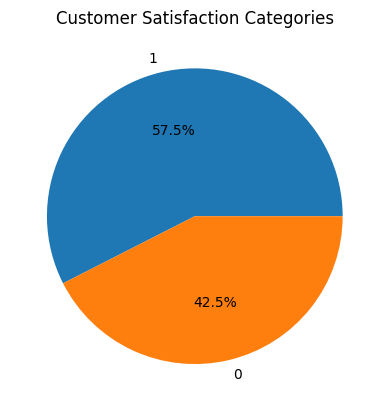

In [90]:
import matplotlib.pyplot as plt

df['customer_satisfaction'].value_counts().plot(kind='pie', autopct='%1.1f%%')

plt.title('Customer Satisfaction Categories')
plt.ylabel('')
plt.show()